# Notebook 9: empirical preparation and first SPX calibration

**Part A is a synthetic acceptance exercise. Part B fits actual exchange bid–ask observations from 18 September 2026 using quote-implied discount and forward inputs.** The first market case is complete, with spread misses and tail sensitivity reported explicitly. The original filename is retained for continuity.

Run `python build_milestone9_notebook.py` from the extracted project folder to recompute both parts, update figures and prose, and rebuild the offline 3D companion from archived inputs. No network access is needed. Earlier notebooks remain preserved.


In [1]:
from run_empirical_preparation import main as prepare_fixture
from build_empirical_report import main as build_fixture_report
fixture_result = prepare_fixture()
fixture_tables = build_fixture_report()


Synthetic preparation: 282 rows, 3 horizons, 10 joint fits, selected lambda=1e-07.
All deliberately invalid metadata/parity cases blocked; row exclusions retain their reasons.
This acceptance exercise is synthetic; market calibration is recorded separately.
Generated Figures 24–25 and computed Tables 23–25; data source table is a documented access assessment.


# Notebook 9, Part A: preparing the empirical calibration

**Synthetic preparation record, retained alongside the subsequent empirical application.** All fitted results in Part A are synthetic acceptance exercises. The supplied marking-price files subsequently enabled the first market case in [Part B](research/marking_methodology.md), which uses an explicitly separate exchange-BBO and quote-implied-carry profile. Notebook 10 and final-paper assembly remain on the [roadmap](research/project_roadmap.md).

## 1. A usable numerical method still needs usable observations

As Bahra explains in his Bank of England paper [1], an option-implied density is a risk-neutral valuation distribution. Its empirical interpretation depends on the option observations and assumptions supplied to the estimator. Earlier notebooks validated the numerical method on known examples and showed why plausible prices or a smooth surface do not establish correct tail recovery. This notebook addresses the next link: what information must be verified before observations can be passed to that method?

The original candidate remains useful as an audit example. Its 27,782 records, zero size fields and incomplete quote-time interpretation have not been reclassified as accepted observations. The candidate file remains unchanged. The initial access assessment below preceded the supplied marking-price files; Part B records their later assessment and different supported profile.

**Table 22. Initial source assessment before the supplied marking-price files.** Product descriptions establish possible routes, not actual access or approval of unseen files.

| Source | Evidence available in this project | Decision for this stage |
|---|---|---|
| Original Cboe page candidate [2] | Archived payload and audit; quote observation datetime/timezone and zero-size meaning remain unresolved | Retain for the data audit; no density fit |
| Cboe Option EOD Summary [18] | Primary layout documentation; advertised sample request returned HTTP 403 | No sample contents inspected; access attempt recorded |
| HistoricalData.net public 2022 sample [19] | Vendor documentation describes asynchronous last-standing quotes; quote timestamps start in August 2026 | Not downloaded: the advertised sample does not meet this study's synchronised-input requirement |
| Institutional OptionMetrics route [20] | WRDS describes option quotes and curve data; no export or institutional access has been supplied | Possible route requiring an actual authorised export and its documentation |

These findings are specific to the accessed material. They do not establish that every public or commercial source is unsuitable. The failed sample request is archived in `data/raw/cboe_eod_sample/retrieval.json`; the other access observations and links are in [data_access_status.md](research/data_access_status.md). No purchase or account access was undertaken.

## 2. A traceable input bundle

The [empirical input guide](research/empirical_input_guide.md) specifies three files: a quote CSV, a discount CSV and a manifest recording the source evidence, conventions and checksums. Empty templates are supplied, together with a separately labelled synthetic example. The first application uses one observation instant, one class, European cash settlement and two or more distinct settlement horizons. It excludes duplicate quotes, unusable sizes, nonpositive or crossed prices, and spreads greater than 25% of midpoint. Exclusion reasons and unmatched counterpart rows remain in the audit.

Complete timestamps include a UTC offset. The code checks whether all quotes belong to the same observation instant, whether settlement follows observation and whether different declarations conflict for an expiry. The elapsed UTC interval is converted to years using ACT/365F. A date-only expiry, file retrieval timestamp or underlying last trade cannot supply a missing quote observation time. Source review must also establish the timestamp's meaning; agreement among strings does not establish genuine synchronisation.

Discounts are keyed to the snapshot and settlement horizon, with observation and availability timestamps. A curve available only after the quote snapshot is rejected. Its maximum permitted age is declared explicitly; the fixture uses one day. A positive discount factor above one is allowed. The required source notes must explain the curve and any tenor conversion. These checks prevent an obvious timing inconsistency but do not establish that a chosen curve is economically appropriate.

The manifest's review record is attributable evidence for the research decision, not an automated certificate. In particular, a valid hash proves neither provenance nor permission. The actual export and documentation must be assessed before a market result is interpreted.

## 3. From matched call–put pairs to a conditional forward

As Aït-Sahalia and Lo discuss in their paper on state-price densities [10, §III.A, Equation (17)], European put–call parity links calls and puts at the same strike and maturity. Our Equation (7) states that relationship, and Equation (8) rearranges it into bid–ask bounds. These bounds condition on the supplied discount factor and matching contract/observation information.

Write the lower and upper bounds from pair $i$ at horizon $m$ as $\ell^F_{mi}$ and $u^F_{mi}$. To use all retained pairs consistently, define

$$
\underline F_m=\max_i\ell^F_{mi},\qquad
\overline F_m=\min_i u^F_{mi},\qquad
\widehat F_m=\frac{\underline F_m+\overline F_m}{2}
\quad\text{when }0<\underline F_m\leq\overline F_m.
\tag{34}
$$

Equation (34) is this project's intersection rule and midpoint convention, derived from Equation (8); it is not a new formula attributed to the paper. The interval is a **conditional compatibility set**, not a statistical confidence interval. Choosing its midpoint is a declared point-input rule, not proof that the midpoint is the true forward or the best estimate under a noise model. No probability distribution for that uncertainty is supplied here.

If the intersection is empty, the code stops before density fitting. A useful diagnostic is the smallest common amount by which all pair intervals would need to be widened on both sides:

$$
s_m^*=\min\{s\geq0:\max_i(\ell^F_{mi}-s)
             \leq\min_i(u^F_{mi}+s)\}
       =\frac{(\underline F_m-\overline F_m)_+}{2}.
\tag{35}
$$

The equality follows because intersection after widening requires $\underline F_m-s\leq\overline F_m+s$. The quantity is in **forward index points**, not a modification to each option quote or an estimate of transaction costs. It is reported without applying the widening. Discarding the binding pair to obtain a convenient forward would change the sample based on the desired answer; that is not done.



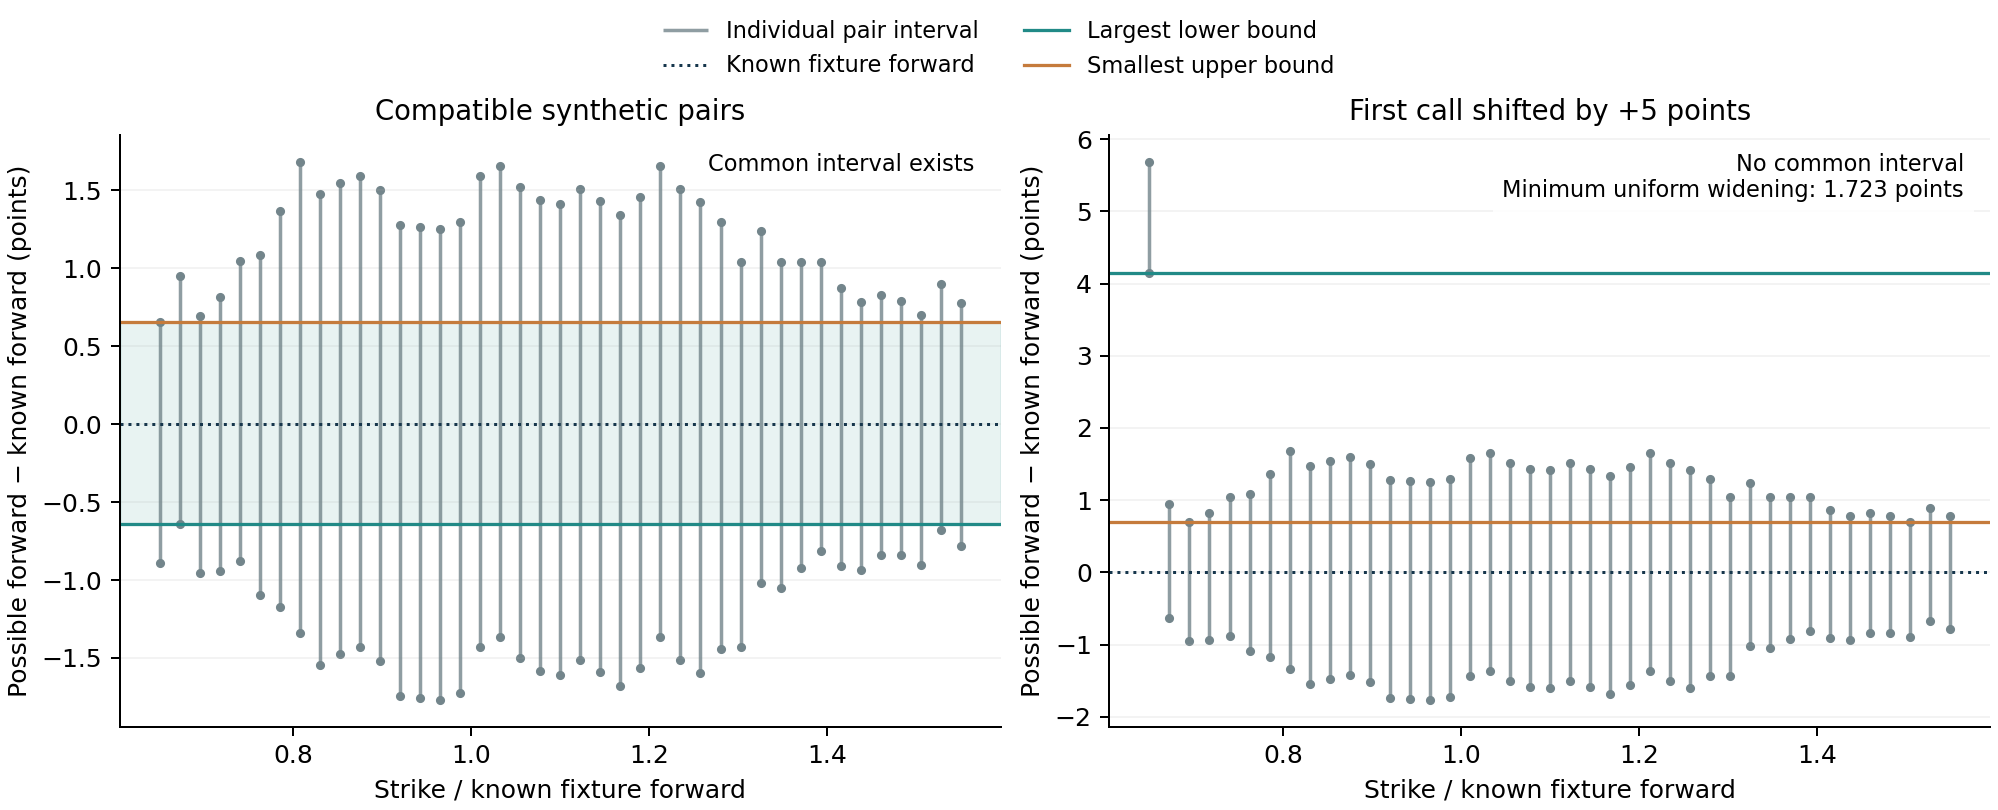




**Figure 24. Conditional forward bounds for the first synthetic horizon.** Each vertical segment is one call–put pair's interval from Equation (8). The left panel has a common intersection. The right panel adds five points to the first call's bid and ask while leaving the put unchanged; the largest lower bound then exceeds the smallest upper bound. The dotted line is the known fixture forward, available only because this example is synthetic. The shaded compatible band is not a confidence interval.

The altered quote still has a positive, ordered bid/ask pair and positive sizes. Its rejection therefore demonstrates a cross-strike compatibility check that ordinary row screening cannot supply. Equation (35) gives a required uniform widening of **1.7234 forward points**. That figure is diagnostic only: the inconsistent case is not calibrated.

## 4. Forward estimation belongs inside model selection

As Cawley and Talbot explain in their model-selection paper [17, §§2.1, 5.1], selecting a tuning parameter is part of the procedure whose performance must be assessed. A further dependency arises here: the forward itself is estimated from quotes. Computing it once from all pairs before cross-validation would let held-out observations influence their own predictions.

The implemented rule holds out a **whole call–put pair** at each selected strike. For each fold, Equation (34) is recomputed from that fold's training pairs only. These training forwards enter the mean constraints, physical density support and residual scaling. Thus the score becomes

$$
\operatorname{CV}_{F}(\lambda)=
\frac{\displaystyle\sum_{k,m}\sum_{i\in\mathcal H_{km}}
\left[\frac{\widehat C_{m,\lambda}^{(-k)}(K_{mi};\widehat F_m^{(-k)})
                 -C^{\mathrm{mid}}_{mi}}{\widehat F_m^{(-k)}}\right]^2}
{\displaystyle\sum_{k,m}|\mathcal H_{km}|},
\qquad \widehat\lambda=\arg\min_{\lambda\in\Lambda}\operatorname{CV}_{F}(\lambda).
\tag{36}
$$

Here $\mathcal H_{km}$ contains held-out pair positions and $\widehat F_m^{(-k)}$ comes exclusively from their complement. This is our application of the separation principle, not an equation copied from [17]. Discounts remain externally supplied inputs and must have been available at the observation. Each expiry can contain a different number of pairs. The three folds interlace interior strikes; both endpoint pairs remain in training. Scores are pooled by the number of evaluated call prices. Exact score ties choose the larger coefficient.

The declared candidate set remains $\Lambda=\{10^{-7},10^{-6},10^{-5}\}$, with 120 common normalised bins on $[0.3,2.2]$. The selected coefficient is refitted using all accepted pairs and their full-data forward intersection. Call midpoints enter the objective. Puts supply parity information and separate residual diagnostics; they are not counted again as independent call observations.

The joint estimator remains the quadratic programme in Equation (17), using the explicit-residual Clarabel formulation described through Goulart and Chen [15]. The normalised calendar restriction follows the assumptions discussed by Gatheral and Jacquier [12]. Its numerical verification uses the analytical within-bin minimum checks from Notebook 5. Passing those checks applies to the fitted discrete horizons under that model, not arbitrary interpolation in observation date or maturity.

This CV score measures fixed-design interior-price interpolation. Endpoints are never held out; it is not an extrapolation score, density-loss selector, historical backtest or unbiased estimate of empirical predictive performance. The lowest candidate can win without locating an optimum beyond the declared grid. These limitations are retained from Notebook 8.

## 5. End-to-end synthetic acceptance exercise

The fixture contains 282 quote rows: 41, 47 and 53 call–put pairs across three nominal horizons. Prices come from the existing two-lognormal mixture, with the constant synthetic rate and dividend inputs. Each analytical price receives a half-spread equal to the smaller of 0.75 points and 8% of that price. Its midpoint is shifted by at most one-fifth of that half-spread, using the saved PCG64 stream with seed `(20260921, 9)`. Thus the clean price remains inside its quoted spread. This construction is a test fixture, not a calibrated microstructure model.

Dates, sizes and quote identifiers are invented. They test the declared input structure and UTC-offset arithmetic; they do not assert actual listed SPXW contracts or exchange opening days. The nominal day labels are convenient fixture names. The exact elapsed horizons used in valuation appear in Table 23, including the offset change between January and the synthetic settlement datetimes.

**Table 23. Verified synthetic input pairs and full-data forward inference.** Interval endpoints, forward estimates and forward errors are in index points. Known forwards are available only for the fixture.

| Nominal horizon | Elapsed years | Pairs | Conditional forward interval | Chosen forward | Error from known forward |
|---|---:|---:|---|---:|---:|
| 60 days | 0.16429795 | 41 | [6024.0571, 6025.3527] | 6024.7049 | +0.0095 |
| 120 days | 0.32868151 | 47 | [6048.6398, 6050.5771] | 6049.6084 | +0.1031 |
| 240 days | 0.65744863 | 53 | [6098.1441, 6100.6864] | 6099.4153 | -0.0169 |

All 282 rows pass the declared screens. The three candidate scores from Equation (36) are **λ = 1e-07: 2.50778e-10; λ = 1e-06: 3.47051e-10; λ = 1e-05: 2.38544e-09**. The selected value is $10^{-7}$, the lower boundary of this small grid. No larger candidate search is performed after inspecting the results. Nine training fits and one selected refit give ten joint fits; this is one functional validation example, not a repeated statistical comparison with Notebook 8.

All 10 joint fits (30 marginals) have solved status and pass the continuous calendar check at tolerance $10^{-8}$. Across their solver histories, the largest mass and normalised-mean residuals are 3.76e-14 and 4.06e-13; the minimum final calendar gap is -7.8e-10. No clipping or renormalisation is applied.

After fitting, the mixture's analytical prices are evaluated at the 138 midpoints between the input strikes, separate from the 141 quoted strikes. These clean prices and the known density are used only for the fixture's subsequent evaluation. Full-domain density errors include the benchmark mass outside the fitted support, as in Equation (23). This verifies a complete route from files to measured recovery error without relabelling the result as empirical evidence.

## 6. Check prices against the supplied spreads

A parity-compatible set can still be difficult to approximate with one constrained, smoothed price curve. For either option type $o$, define its distance outside the quoted interval as

$$
d^{\mathrm{spread}}_{mi,o}
=\max\{B_{mi,o}-\widehat V_{mi,o},\,
          \widehat V_{mi,o}-A_{mi,o},\,0\}.
\tag{37}
$$

This is a project diagnostic in index points, not a statistical test. Call values come from exact bin-payoff integration, Equation (11); put values follow Equation (7) using the same fitted forward and discount. A positive distance greater than $10^{-7}$ points is counted as outside. The calculation checks all retained calls and puts even though only call midpoints enter the price objective.

**Table 24. Independent fixture recovery and in-sample spread diagnostics.** The clean-price column uses separate strike midpoints. The spread columns assess the supplied input quotes; the two roles should not be conflated.

| Nominal horizon | Separate clean-price RMSE (points) | Full-domain density L1 | Quotes outside spread | Largest spread distance (points) |
|---|---:|---:|---:|---:|
| 60 days | 0.05257 | 0.04960 | 1 / 82 | 0.01993 |
| 120 days | 0.05195 | 0.04411 | 0 / 94 | 0.00000 |
| 240 days | 0.03808 | 0.06150 | 0 / 106 | 0.00000 |



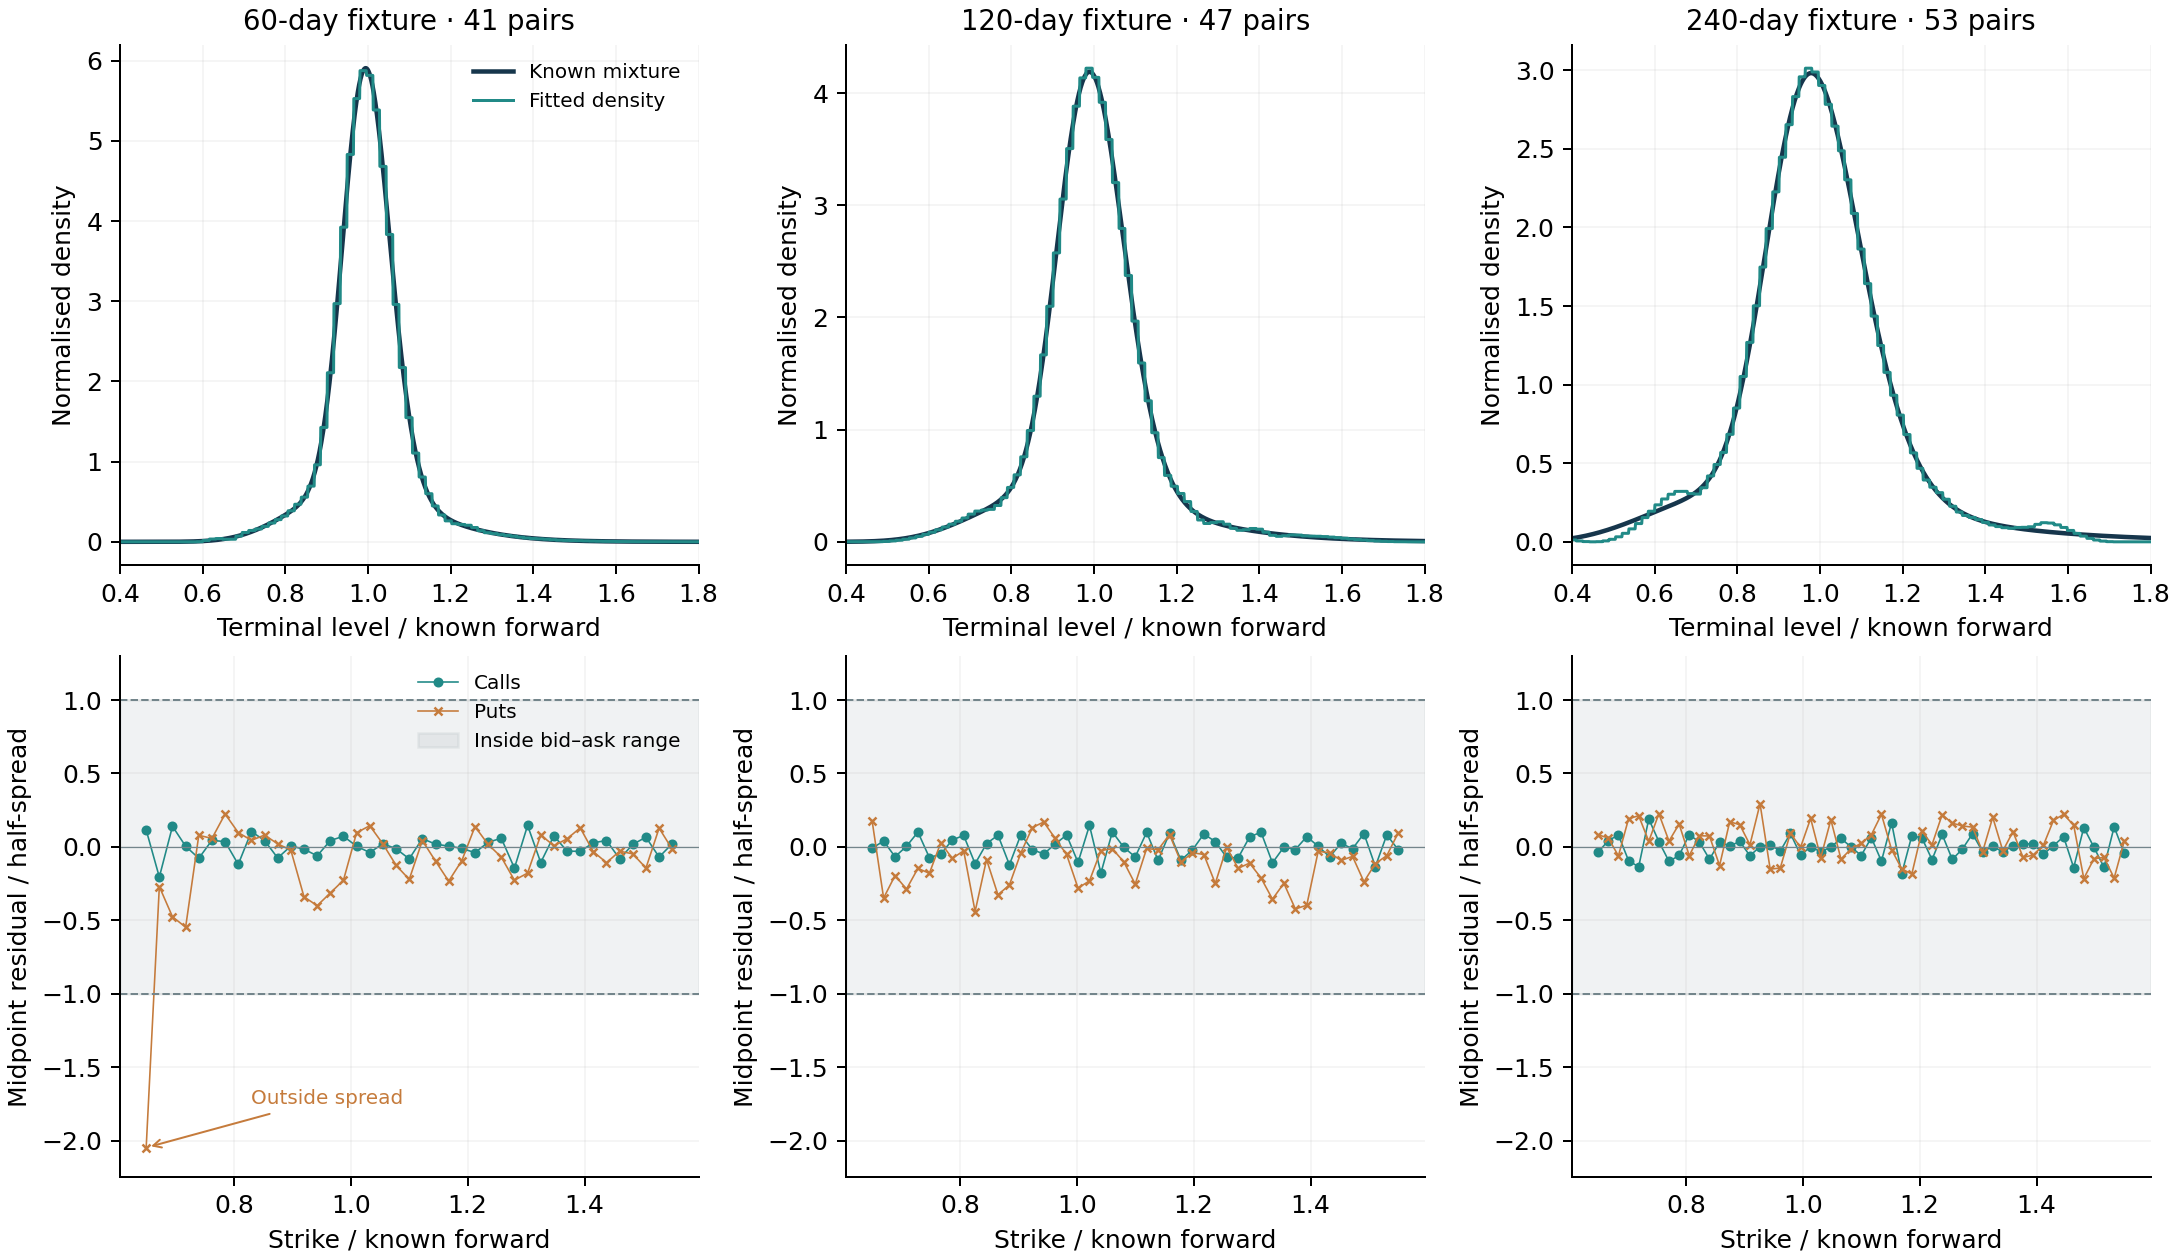




**Figure 25. Density recovery and quote-range checks in the synthetic fixture.** The upper panels compare the fitted histogram with the known mixture in fixed reference-forward coordinates. Only $0.4$–$1.8$ is displayed; Table 24's density error covers the full positive domain. The lower panels divide midpoint residuals by each quote's half-spread: values between $-1$ and $1$ lie inside the bid/ask interval. Both option types are shown. Half-spreads are positive in this fixture; the stored point-distance diagnostic also works for a valid zero-width quote.

One quote in the first horizon lies approximately **0.01993 index points** outside its range. The result is retained. It does not contradict parity feasibility: pairwise compatibility with a forward does not assert that the regularised density will price all pairs inside their spreads. The existing objective uses midpoint residuals, not bid/ask constraints. Nor does the result prove that a fit satisfying every spread is impossible. Such a feasibility question would require an additional constrained problem. As Notebook 8 already showed, a small price error and a satisfactory density error are also different targets.

## 7. Deliberately invalid inputs and development lessons

**Table 25. Input-failure exercises applied to the saved fixture.** These are designed checks, not failures discovered in market observations. Mutations and returned reasons are retained in `results/empirical_preparation.json`.

| Deliberate input change | Observed response |
|---|---|
| Missing quote timezone | Blocked |
| Unsynchronised quote | Blocked |
| Conflicting settlement time | Blocked |
| Discount published after the snapshot | Blocked |
| Discount older than the declared limit | Blocked |
| Call bid and ask at the first strike increased by 5 points | Blocked by parity |
| Zero size and a duplicated call quote | 5 rows excluded |

Additional unit checks alter held-out prices while keeping their training pairs unchanged, then verify that the corresponding training forward and predictions are unchanged. Saved CV scores are reconstructed from the archived weights and training-only forwards. The constraints of all ten fits are checked independently, and all eight earlier notebooks plus both 3D companions are matched against their Milestone 8 checksums.

The principal setbacks at this stage were unavailable sample access and unsuitable metadata in another advertised sample. They were not resolved by a successful solver run. The useful response was to make the missing empirical requirements explicit and implement the parts that could be validated with known inputs. During that implementation, the quote-derived forward dependency was identified and included within each fold. The remaining spread residual illustrates why input compatibility, numerical convergence and quote reproduction require separate evidence.

The [development reflection](research/development_reflection.md) records these preparation-stage observations alongside the earlier notebooks. [Part B](research/marking_methodology.md) subsequently assesses the supplied files, explains its separate quote-implied-carry profile and reports the first empirical calibration with the remaining fit limitations. Notebook 10 will compare the reserved observations; the existing offline maturity explorers remain available.

## Sources and reproducibility

Full records and source-to-relationship mappings are in [references.md](research/references.md). Bahra [1] supplies the risk-neutral interpretation; Aït-Sahalia and Lo [10] supplies the parity foundation; Cawley and Talbot [17] supports separation of selection and evaluation; Gatheral and Jacquier [12] and Goulart and Chen [15] support the calendar and solver discussions. Equations (34)–(37), thresholds, fixture construction and numerical results are explicitly this project's definitions and calculations. Provider sources [18]–[20] establish operational documentation only.

Run `python build_milestone9_notebook.py` from the project folder to regenerate the fixture, execute the calibration exercise, rebuild figures and tables and write the explanatory notebook. `run_market_calibration.py` is the separate entry point for a reviewed bundle; it does not fetch data. The [input guide](research/empirical_input_guide.md) includes the format and command. Numerical evidence, source checksums, fixture hashes, row-level audit, fold membership, training forwards, solver histories and fitted probabilities are retained in `results/empirical_preparation.json`.


# Part B: observed SPXW quotes

The following cell runs the primary empirical protocol, then the explicitly labelled post-hoc range diagnostic. The narrative below records their distinct roles.


In [2]:
from run_marking_calibration import main as calibrate_market
from run_marking_diagnostic import main as diagnose_range
from build_marking_report import main as build_market_report
from build_marking_html import main as build_market_explorer
market_result = calibrate_market()
range_diagnostic = diagnose_range()
market_tables = build_market_report()
explorer_path = build_market_explorer()


Actual exchange BBO: 969 matched pairs; selecting across three penalties.
Selection complete: lambda=1e-07. Refit all candidates for sensitivity.
Full sample lambda=1e-07: calendar minimum -1.88e-15.
Full sample lambda=1e-06: calendar minimum -2.63e-10.
Full sample lambda=1e-05: calendar minimum -1.34e-14.
Completed 12 joint fits. Selected fit: 650 / 1938 fitted call/put prices outside their spreads (tolerance 1e-7 points).
Post-hoc lambda=1e-10: 501 outside spreads.
Post-hoc lambda=1e-09: 496 outside spreads.
Post-hoc lambda=1e-08: 556 outside spreads.
Lower-grid scores: [(1e-10, 2.849965181538961e-09), (1e-09, 2.9270287536721256e-09), (1e-08, 3.4798057175388194e-09)]
Generated empirical Figures 26–28 and Tables 26–30.
Built empirical_density_surface.html; all scripts and fitted data included for offline use.


# Notebook 9, Part B: the first empirical SPX calibration

**Status: first empirical case completed, with material fit and tail limitations retained.** The three supplied CSVs are adequate for this explicitly defined exchange-BBO study. They provide two observation dates, not three: 31 August and 18 September 2026. The latter has two intraday snapshots. Part A remains a synthetic preparation exercise; the results below use observed market-price columns. Notebook 10 will use the reserved observations for comparison after addressing the limitations identified here. The combined paper remains a separate assembly stage.

## 8. What the supplied files establish

Cboe's marking-price documentation [21] distinguishes indicative marks from actual exchange BBO and states that both are included in its CSVs. Accordingly, this application reads `call_last_disseminated_market_bid/ask` and their put equivalents. It does not use the final indicative prices. The archived inputs match the three publicly linked Cboe downloads byte-for-byte; the HTTP results, byte counts and SHA-256 values are recorded in `data/raw/marking_prices/source_verification.json`. The snapshot labels come from the linked products, and the dates agree with every SPX-family message in each file. These observations establish the source-specific interpretation used here, rather than retroactively accepting the earlier candidate JSON.

**Table 26. Supplied file coverage and assigned role.** Each target row contains a call and put at one strike. Counts include all SPX/SPXW expiries before screening. CT means Chicago civil time; all three observation dates are on UTC−05:00.

| File | Date | CT | All rows | SPX/SPXW pairs | Use here |
|---|---|---|---|---|---|
| eom_marking_prices_list.csv | 2026-08-31 | 15:00 | 39,945 | 13,813 | reserved date comparison |
| eod_marking_prices_list.csv | 2026-09-18 | 15:00 | 39,346 | 13,891 | primary calibration |
| eod_marking_prices_late_list.csv | 2026-09-18 | 15:15 | 38,995 | 13,891 | reserved intraday comparison |

The September 15:15 CT file is a later observation of the same day. Concatenating it with the 15:00 file would mix observation instants and double-count many contracts. The August file is a second date, sufficient for a small comparison, but two dates do not supply a historical time series or an event-study sample. Both reserved files are audited here and retained unchanged for Notebook 10.

All indicative bid/ask size entries in the SPX-family rows are `1`. These are **not demonstrated market depth** and do not satisfy the positive actual-size profile used in Part A. A separate adapter, `src/marking.py`, therefore records actual size as unavailable, uses the documented exchange BBO and makes no NBBO or executable-depth claim. The original external-curve/NBBO adapter remains unchanged. This is an explicit change of empirical profile based on new source evidence, not a relabelling of failed observations.

## 9. Contract scope, timing and screening

For the first case, the protocol fixes the 18 September 15:00 CT snapshot and the SPXW expiries **16 October, 20 November and 18 December 2026**. These give approximately one-, two- and three-month horizons while keeping a common PM settlement class. Other expiries are retained in the raw files and excluded with a scope reason. As Cboe's contract specifications and holiday schedule establish [5, 22], these are ordinary full-session SPXW dates; settlement is represented by 16:00 New York time. The October offset is UTC−04:00 and the later offsets are UTC−05:00. Elapsed UTC seconds divided by 365 days give 28, 63 + 1/24 and 91 + 1/24 days. The extra hour is the daylight-saving transition, not an extra market session.

The adapter verifies OSI root, expiry, option type and encoded strike against the row. It requires both sides of a matched pair to have finite positive, ordered prices and a full spread no greater than 25% of midpoint. Duplicates are excluded without averaging. A declared activity screen requires both message timestamps to be at most 60 seconds old and no later than the documented snapshot. Individual message times are last-update information within a snapshot; their inequality alone does not establish that the source lacks a common as-of book state. The activity screen is a research choice, not proof of execution availability.

No SPX-family row has an unresolved metadata failure in these files. The primary file contains 13,891 target pairs; 11,936 pass the price screen and 11,835 also pass the age screen across all target roots and expiries. The three selected SPXW expiries retain **364, 344 and 261 pairs**, respectively: **969 pairs and 1,938 individual option quotes**. All selected price-screened pairs pass the age screen. Every target row retains its screening and scope reasons in `results/marking_input_audit.json`; all non-target rows remain in the original CSVs.

## 10. Inferring discount and forward together

The CSVs do not supply a discount curve. As Aït-Sahalia and Lo explain through European put–call parity [10, §III.A], call and put prices link strike, discounting and the forward. Instead of inserting an unobserved rate, this application estimates a **quote-implied carry proxy**. With $H_m=D_mF_m$, Equation (7) becomes linear in the two unknowns:

$$
C_{mi}-P_{mi}=H_m-D_mK_{mi},\qquad
b^-_{mi}=C^{\mathrm{bid}}_{mi}-P^{\mathrm{ask}}_{mi},\qquad
b^+_{mi}=C^{\mathrm{ask}}_{mi}-P^{\mathrm{bid}}_{mi}.
\tag{38}
$$

Let $y_{mi}=C^{\mathrm{mid}}_{mi}-P^{\mathrm{mid}}_{mi}$ and let $K_{0m}$ be the median retained strike. Our point-input convention is equal-weight constrained least squares:

$$
(\widehat H_m,\widehat D_m)=
\underset{H,D}{\arg\min}\;\frac{1}{N_m}\sum_{i=1}^{N_m}
\left(\frac{H-DK_{mi}-y_{mi}}{K_{0m}}\right)^2,
\quad
\begin{cases}
b^-_{mi}\le H-DK_{mi}\le b^+_{mi},&\text{all retained }i,\\
D\ge\varepsilon_{\mathrm{carry}},\quad H\ge\varepsilon_{\mathrm{carry}} K_{0m},&\varepsilon_{\mathrm{carry}}=10^{-8},
\end{cases}
\quad\widehat F_m=\frac{\widehat H_m}{\widehat D_m}.
\tag{39}
$$

Equations (38)–(39) are this project's rearrangement and estimation rule, not a formula quoted from the paper. As Boyd and Vandenberghe describe in *Convex Optimization* [11], a convex quadratic objective with linear restrictions admits a quadratic-programme formulation. The implementation centres the strike coordinate and solves for $\beta_0=(H-DK_0)/K_0$ and $\beta_1=D$. An unconstrained least-squares solution is accepted only when it satisfies every restriction; otherwise the two-variable QP uses Clarabel with strict solved status [15]. An empty or unbounded discount-feasibility projection blocks calibration. In this primary sample, the unconstrained optima are already feasible.

Two linear programmes minimise and maximise $D$ over the same bid–ask set. Their interval is a **feasible projection**, not a confidence interval. The forward is then checked independently against the conditional interval in Equation (34), but is the regression-implied value from Equation (39), not that interval's midpoint. The interval's midpoint remains a diagnostic field inherited from the preparation routine and is not the market fit's chosen forward. A positive $D>1$ is allowed: an inferred negative rate is not rejected by fiat.

For interpretation only, a constant continuously compounded rate equivalent is

$$
\widehat r_m=-\frac{\log\widehat D_m}{T_m}.
\tag{40}
$$

Equation (40) is an algebraic transformation of the fitted discount. It is **not an independently observed risk-free rate**, a Treasury/OIS curve or evidence of a specific funding mechanism. Bid–ask effects and departures from the assumed common parity inputs can affect this estimate. No external curve sensitivity or joint statistical uncertainty is claimed in this stage.

**Table 27. Full-sample quote-implied carry inputs.** The discount intervals project all retained pair inequalities. Forward values are in index points; the last column is the equivalent annual rate, expressed as a percentage. Reporting digits aid reconstruction and do not imply this degree of economic precision.

| Expiry | Pairs | Elapsed days | Inferred D | Feasible D range | Inferred F (points) | Implied rate (%/yr) |
|---|---|---|---|---|---|---|
| 2026-10-16 | 364 | 28.00000 | 0.99692766 | [0.99355705, 1.00051635] | 7666.5433 | 4.0112 |
| 2026-11-20 | 344 | 63.04167 | 0.99259513 | [0.99038168, 0.99531840] | 7691.7365 | 4.3032 |
| 2026-12-18 | 261 | 91.04167 | 0.98895253 | [0.98664835, 0.99123243] | 7712.2104 | 4.4537 |

## 11. Selection, joint calibration and observed spread misses

As Cawley and Talbot explain [17], evaluation must account for the complete selection procedure. Whole call–put pairs are therefore held out together in the three interlaced interior-strike folds. **Both discount and forward** are re-estimated from each fold's training pairs using Equation (39); held-out pairs cannot determine either input. The score is Equation (36) with the call predictor also conditioned on the training-only discount. Endpoints remain in training, so the 963 held-out predictions assess interpolation over observed interior strikes, not performance at unobserved tail strikes or future dates. This score is the tuning criterion and is not an independent final performance estimate.

The primary candidate grid remains $\{10^{-7},10^{-6},10^{-5}\}$, with the existing 120 equal-width bins on $S/F\in[0.3,2.2]$. There are nine training fits and three full-data refits; the selected refit is reused. As Goulart and Chen's solver paper describes [15], the explicit-residual conic formulation supports the quadratic objective without changing the pricing representation. The project retains its existing mass, mean and continuous calendar checks.

As Gatheral and Jacquier's calendar argument shows [12], ordering normalised call values across maturities depends on the carry model. Here deterministic carry and proportional dividends are **modelling assumptions** applied to inferred inputs. The index's actual cash-dividend process is not reconstructed. Passing the implemented inequalities does not establish arbitrage freedom under every real-market funding/dividend specification, nor does it establish an interpolated maturity model.

The primary grid selects its weakest coefficient, **$\lambda=10^{-7}$**. Its fitted calls closely overlap observed midpoints on the price scale, yet **650 of 1,938 call/put values are outside their bid–ask ranges** at a $10^{-7}$-point counting tolerance. The largest miss is approximately **1.8661 index points**. These are in-sample residuals, with no spread constraint imposed by the objective. Parity feasibility asserts that each pair can accommodate the inferred line; it does not guarantee that the particular regularised call curve also satisfies both quoted intervals.

**Table 28. Primary selected fit and quote coverage.** RMSE uses retained midpoints. The outside counts separate calls and puts; each has the pair count in Table 27. A low price RMSE does not certify a recovered density.

| Expiry | Retained K/F range | Call RMSE (points) | Put RMSE (points) | Calls / puts outside | Largest spread miss (points) |
|---|---|---|---|---|---|
| 2026-10-16 | 0.6261–1.0905 | 0.8895 | 1.0036 | 100 / 236 | 1.8661 |
| 2026-11-20 | 0.4680–1.1571 | 0.4477 | 0.8228 | 36 / 145 | 1.3688 |
| 2026-12-18 | 0.4149–1.2188 | 0.3323 | 0.7146 | 6 / 127 | 0.6305 |



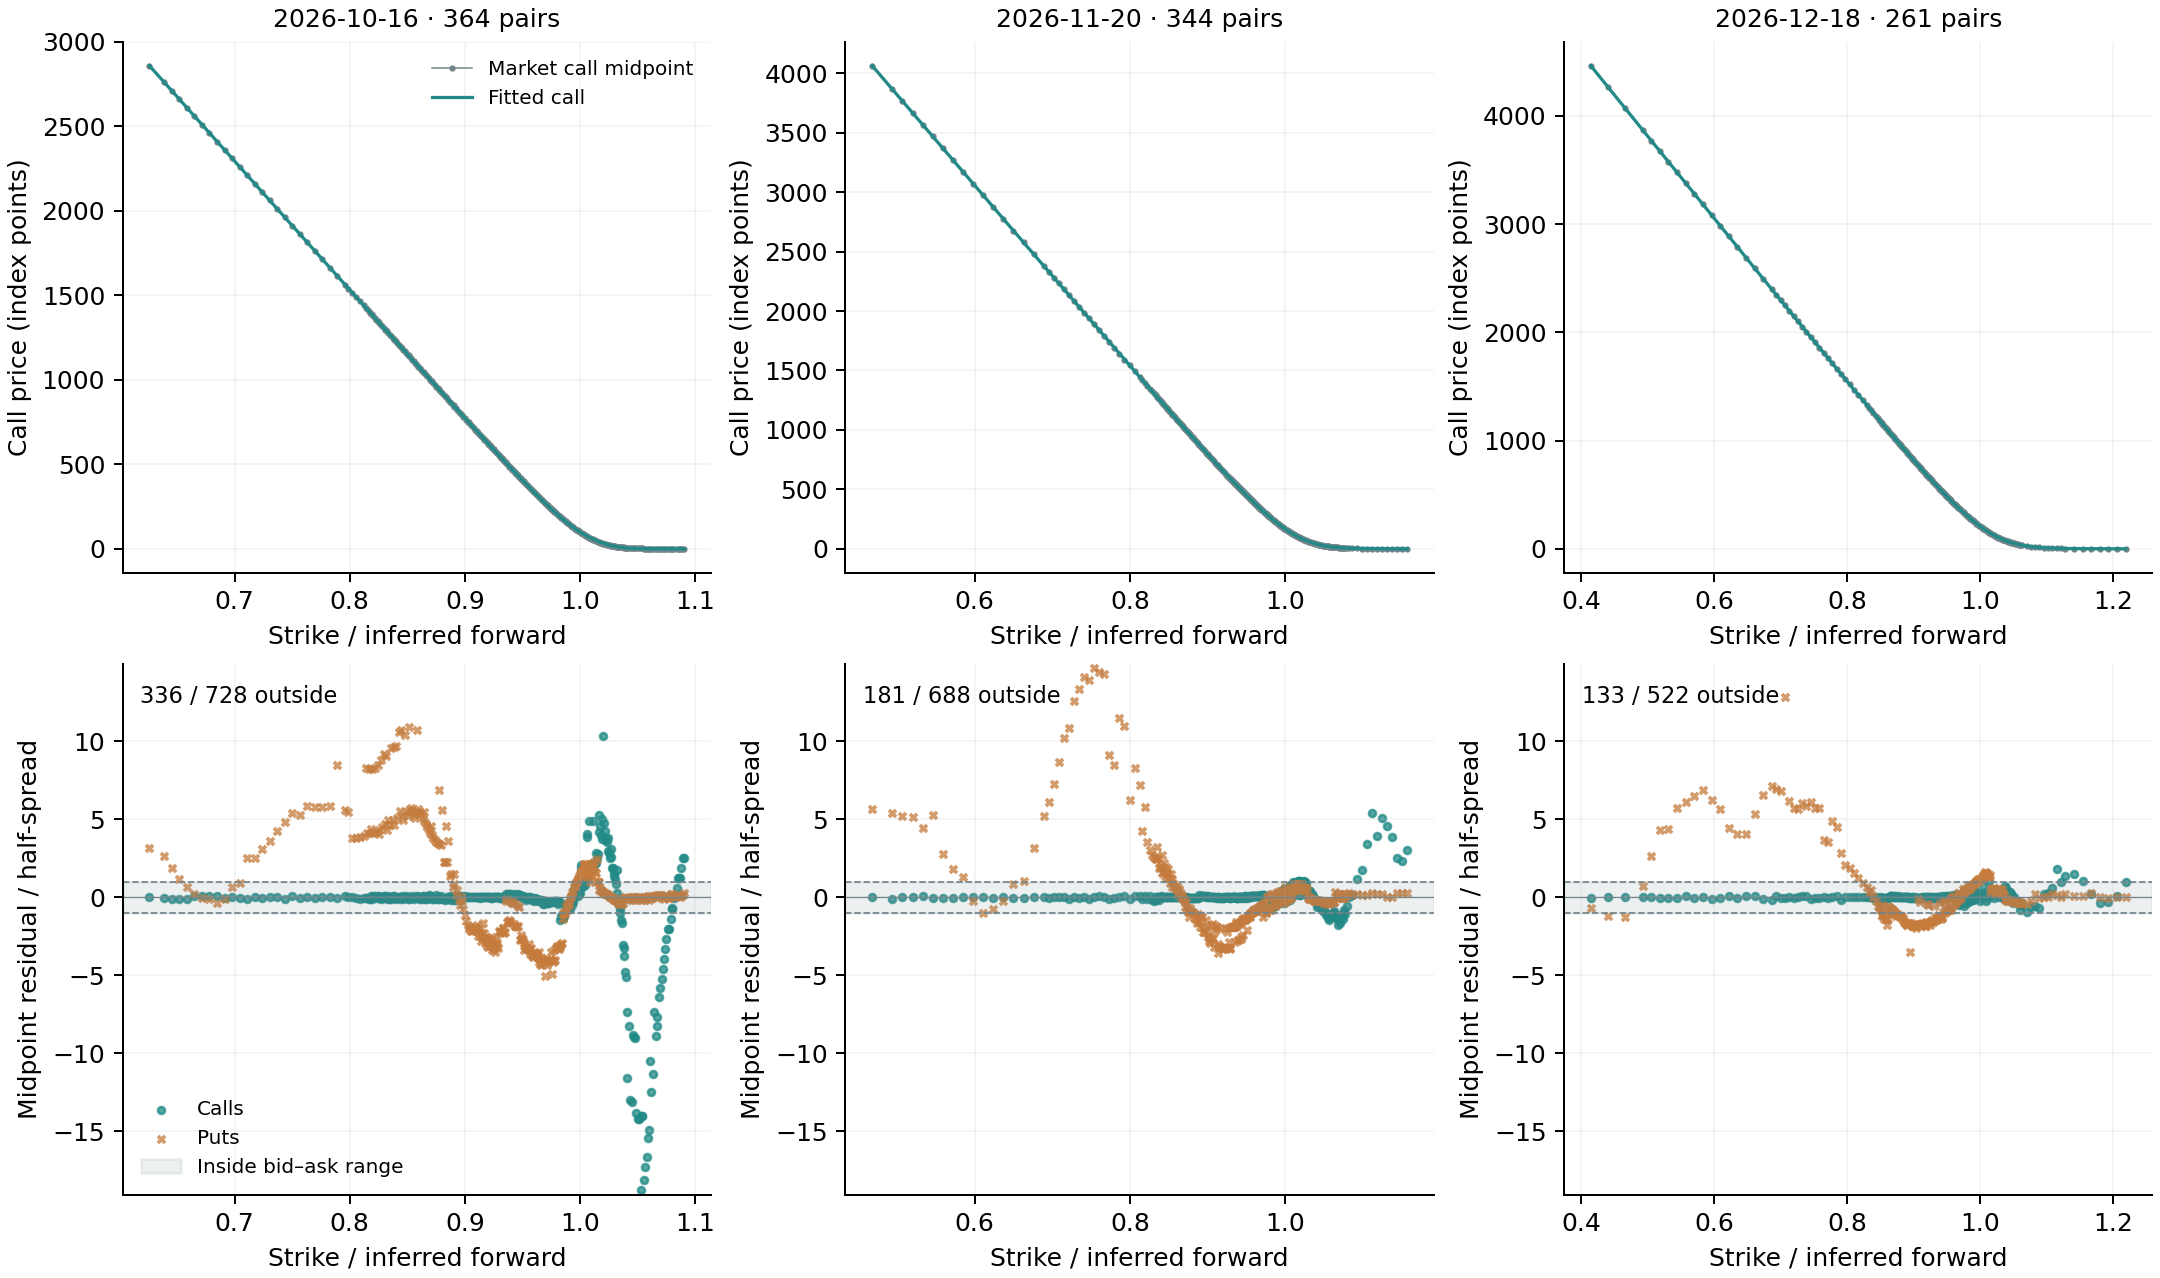




**Figure 26. Primary market fit and bid–ask residuals on 18 September 2026.** Upper panels show market call midpoints and the selected fitted call curve. Lower panels show both option types in units of their own half-spread. The shaded band is the bid–ask interval. The common vertical range covers every residual; misses are retained rather than clipped. Prices are index points, not dollars per contract. All retained spreads in this case have positive width.

The lower panels demonstrate why a visually close price curve is insufficient evidence of quote reproduction. Put values follow the fitted call and Equation (38), whereas the loss function targets call midpoints. The narrower put spreads can make modest point residuals large in half-spread units. No quotes are shifted, no forward is reselected to conceal the misses and no density-recovery error is reported against an invented market truth.

## 12. A boundary choice prompted a separate diagnostic

The weakest primary candidate won while numerous prices missed their spreads. This observed result motivated an explicitly **post-hoc** lower grid, $\{10^{-10},10^{-9},10^{-8}\}$, using the same folds, support, carry rule and solver criteria. Its nine training fits and three full-data fits are saved separately in `results/marking_range_diagnostic.json`, with the primary-result checksum. It does not replace the primary protocol, and reusing the data after inspecting results supplies no independent validation.

**Table 29. Declared primary grid and subsequent lower-penalty diagnostic.** Scores pool held-out call errors divided by training forwards. The outside-spread and maximum-miss columns instead describe full-data refits, so they need not rank coefficients in the same order.

| Role | λ | Pooled held-out score | Outside spreads | Largest miss (points) |
|---|---|---|---|---|
| Primary | 1e-07 | 7.077784e-09 | 650 / 1938 | 1.8661 |
| Primary | 1e-06 | 3.906252e-08 | 896 / 1938 | 5.7016 |
| Primary | 1e-05 | 2.482028e-07 | 1083 / 1938 | 13.8752 |
| Post-hoc | 1e-10 | 2.849965e-09 | 501 / 1938 | 1.3915 |
| Post-hoc | 1e-09 | 2.927029e-09 | 496 / 1938 | 1.3963 |
| Post-hoc | 1e-08 | 3.479806e-09 | 556 / 1938 | 1.3791 |

The diagnostic selects $10^{-10}$, again at its lower boundary. Its score is approximately **60% below** the primary grid's selected score, but **501 prices still miss their spreads: three calls and 498 puts**. The $10^{-9}$ fit has fewer total misses, 496, while a slightly worse call-price score. Thus choosing a coefficient to predict call midpoints is not equivalent to choosing it to satisfy both sides' quoted intervals. The tested grid has not located an interior optimum, and these results do not establish that ever-weaker smoothing is desirable. A future comparison should predeclare any revised selection rule and assess a joint call/put or spread-feasibility formulation, not silently optimise the reported miss count.



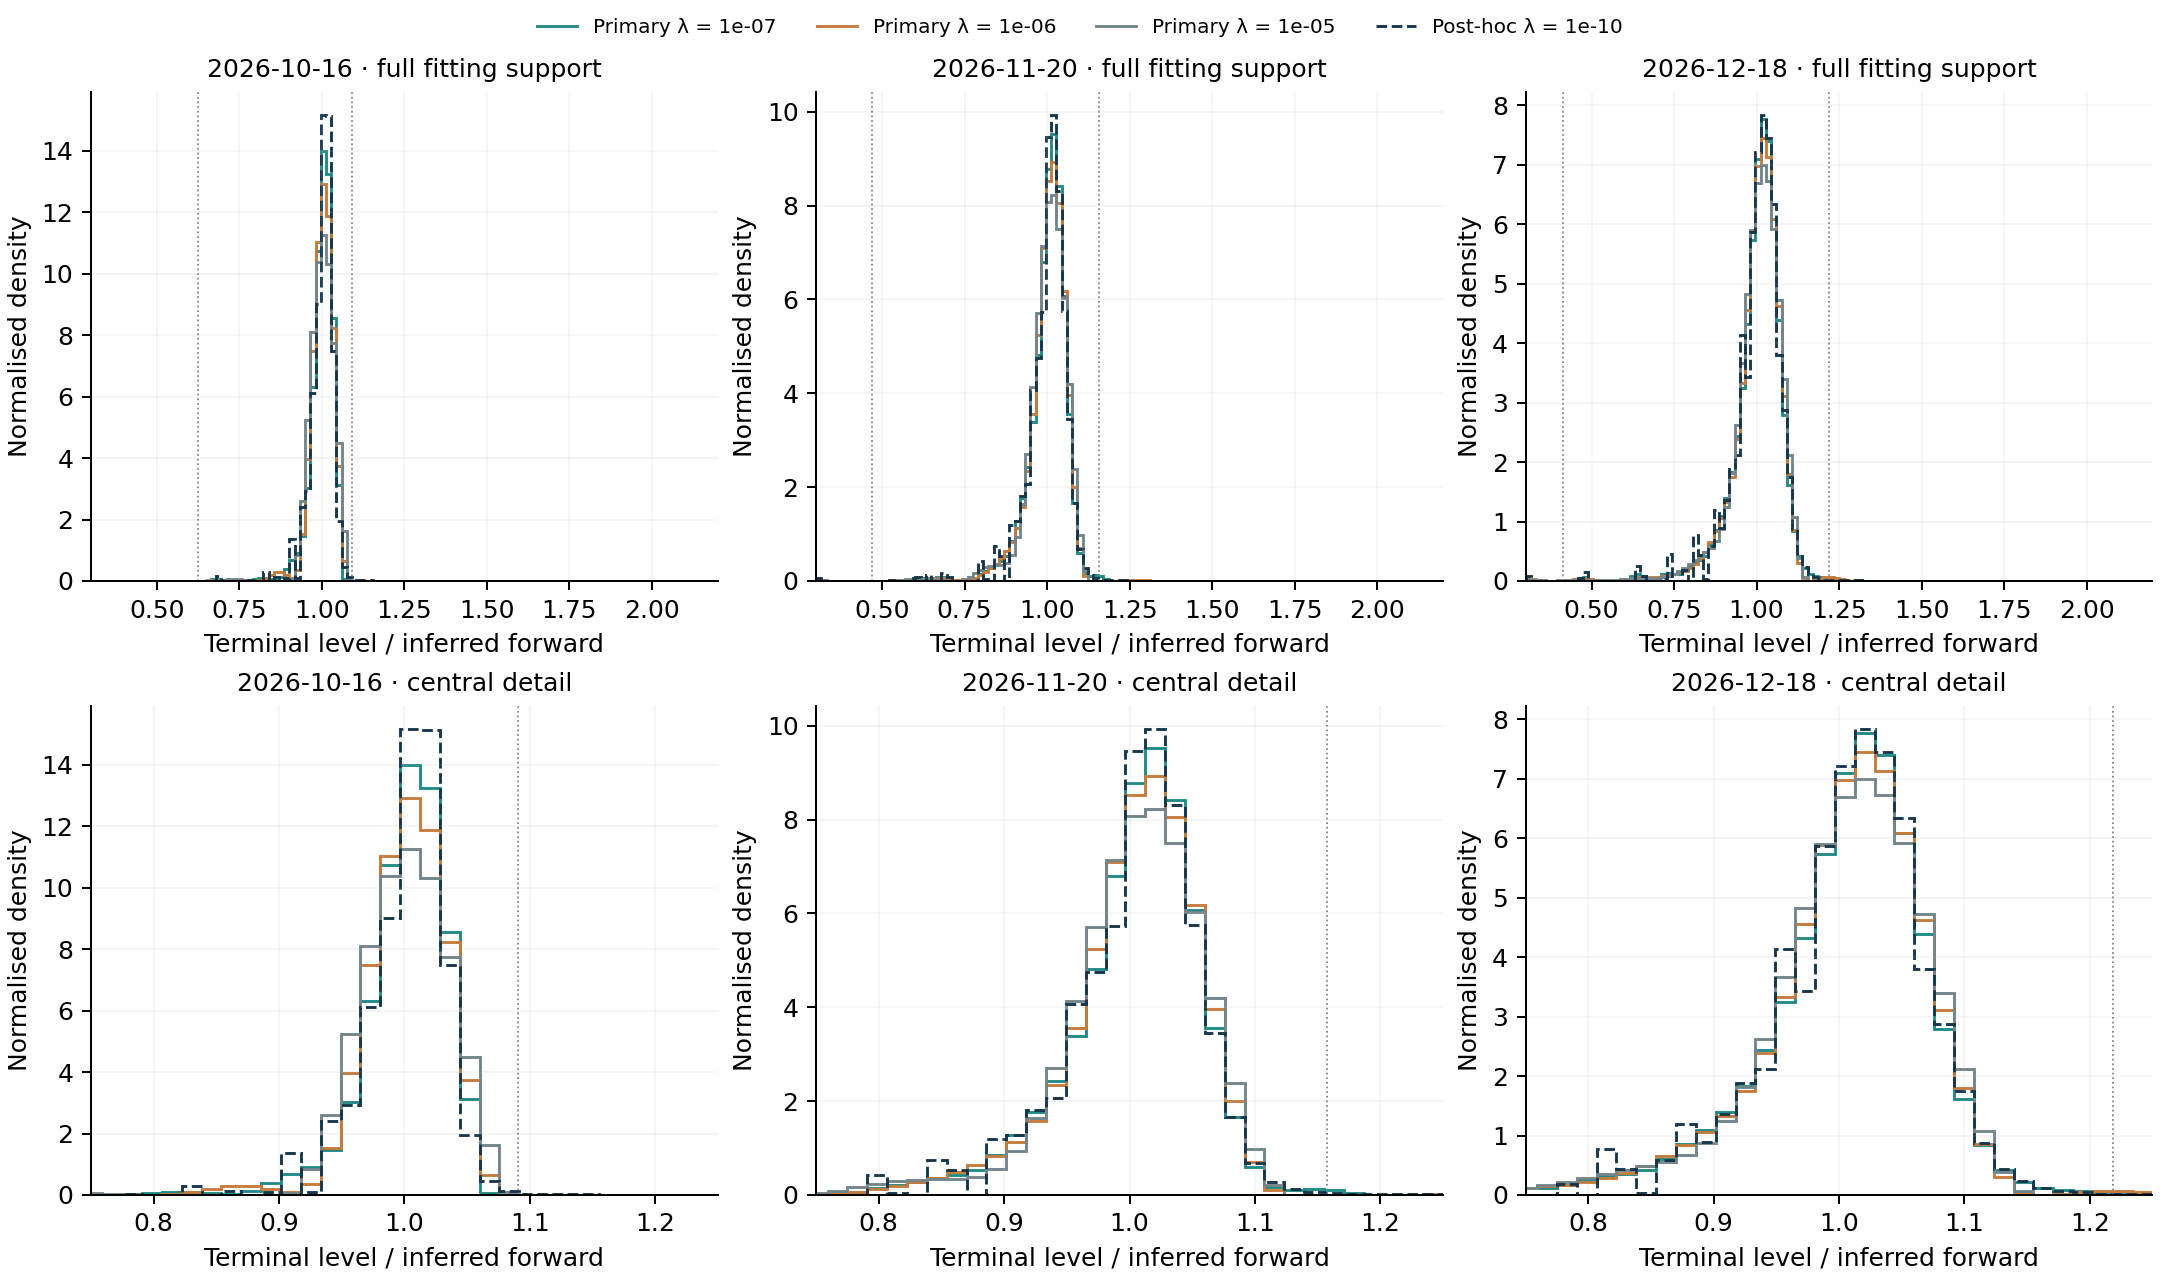




**Figure 27. Market-density sensitivity to smoothing.** The three solid curves use the declared primary coefficients; the dashed curve uses the post-hoc selected $10^{-10}$. Top panels show the entire fitting support and lower panels enlarge $0.75\le S/F\le1.25$. Dotted vertical lines delimit the retained strike range. Curves are estimated histograms, not analytical benchmark densities. Tiny far-tail masses are easier to compare numerically in Table 30 than on this peak-dominated linear scale.

As Malz discusses in his research on option-based distributions [14, §§2.3 and 3.2], extrapolation deserves separate attention when interpreting tail summaries. Here the primary retained upper strikes are only about **1.0905F, 1.1571F and 1.2188F**. The $1.2F$ threshold exceeds observed coverage in the first two horizons, while $1.8F$ exceeds it in all three. Even when a threshold itself is covered, its upper-tail integral still extends beyond observed strikes. The $0.8F$ threshold falls within the retained range at all three horizons, but that alone does not identify the entire lower tail.

**Table 30. Conditional risk-neutral summaries for the primary and post-hoc selected fits.** Probabilities are percentages; variance is dimensionless. These are sensitivity outputs, not confidence intervals, physical forecasts or recommendations. Values near numerical resolution should not be read as precise market probabilities.

| Fit | Expiry | Q(S < 0.8F), % | Q(S > 1.2F), % | Q(S > 1.8F), % | Var(S/F) |
|---|---|---|---|---|---|
| Primary 1e−7 | 2026-10-16 | 0.37970 | 0.0096739 | 0.009673851 | 0.0016523 |
| Primary 1e−7 | 2026-11-20 | 1.24439 | 0.0096739 | 0.009673851 | 0.0044610 |
| Primary 1e−7 | 2026-12-18 | 2.34564 | 0.1486140 | 0.009673850 | 0.0068258 |
| Post-hoc 1e−10 | 2026-10-16 | 0.37272 | 0.0000078 | 0.000001186 | 0.0015441 |
| Post-hoc 1e−10 | 2026-11-20 | 1.35610 | 0.0997905 | 0.000049443 | 0.0043609 |
| Post-hoc 1e−10 | 2026-12-18 | 2.06036 | 0.1797615 | 0.000218654 | 0.0067438 |

The primary first-horizon $Q(S_T>1.8F)$ is about 0.009674%, versus about 0.000001186% in the weaker diagnostic fit. This difference is orders of magnitude despite the small absolute probabilities. It illustrates weakly determined extrapolation; it is not evidence that either figure is the correct probability. As Bahra emphasises in the Bank of England paper [1], the probability measure recovered from option valuation is risk-neutral, so these outputs are not direct real-world crash or rally forecasts.

## 13. Numerical evidence and the empirical 3D companion

All 24 empirical joint fits (72 marginals), including the post-hoc diagnostic, have strict solved status and pass the continuous calendar check at $10^{-8}$. The minimum final gap is -5.749e-10; largest mass and normalised-mean residuals are 1.776e-15 and 2.376e-14. The smallest signed mass is -1.635e-16, retained without clipping or renormalisation.

These checks cover the 12 primary fits plus the 12 diagnostic fits. The earlier synthetic acceptance exercise remains separate. Independent checks reconstruct the training carry, pooled scores, call/put residuals and risks from saved weights; test exact parity including $D>1$; exercise a bound-active QP and an incompatible parity set; and verify that indicative fields and held-out pair changes cannot alter the wrong inputs. One deliberately invalid single-row fixture initially exposed an empty timestamp-summary error. The adapter now retains an explicit metadata rejection with unavailable extrema instead of failing before it can report the problem. Valid market results are unchanged by that correction.



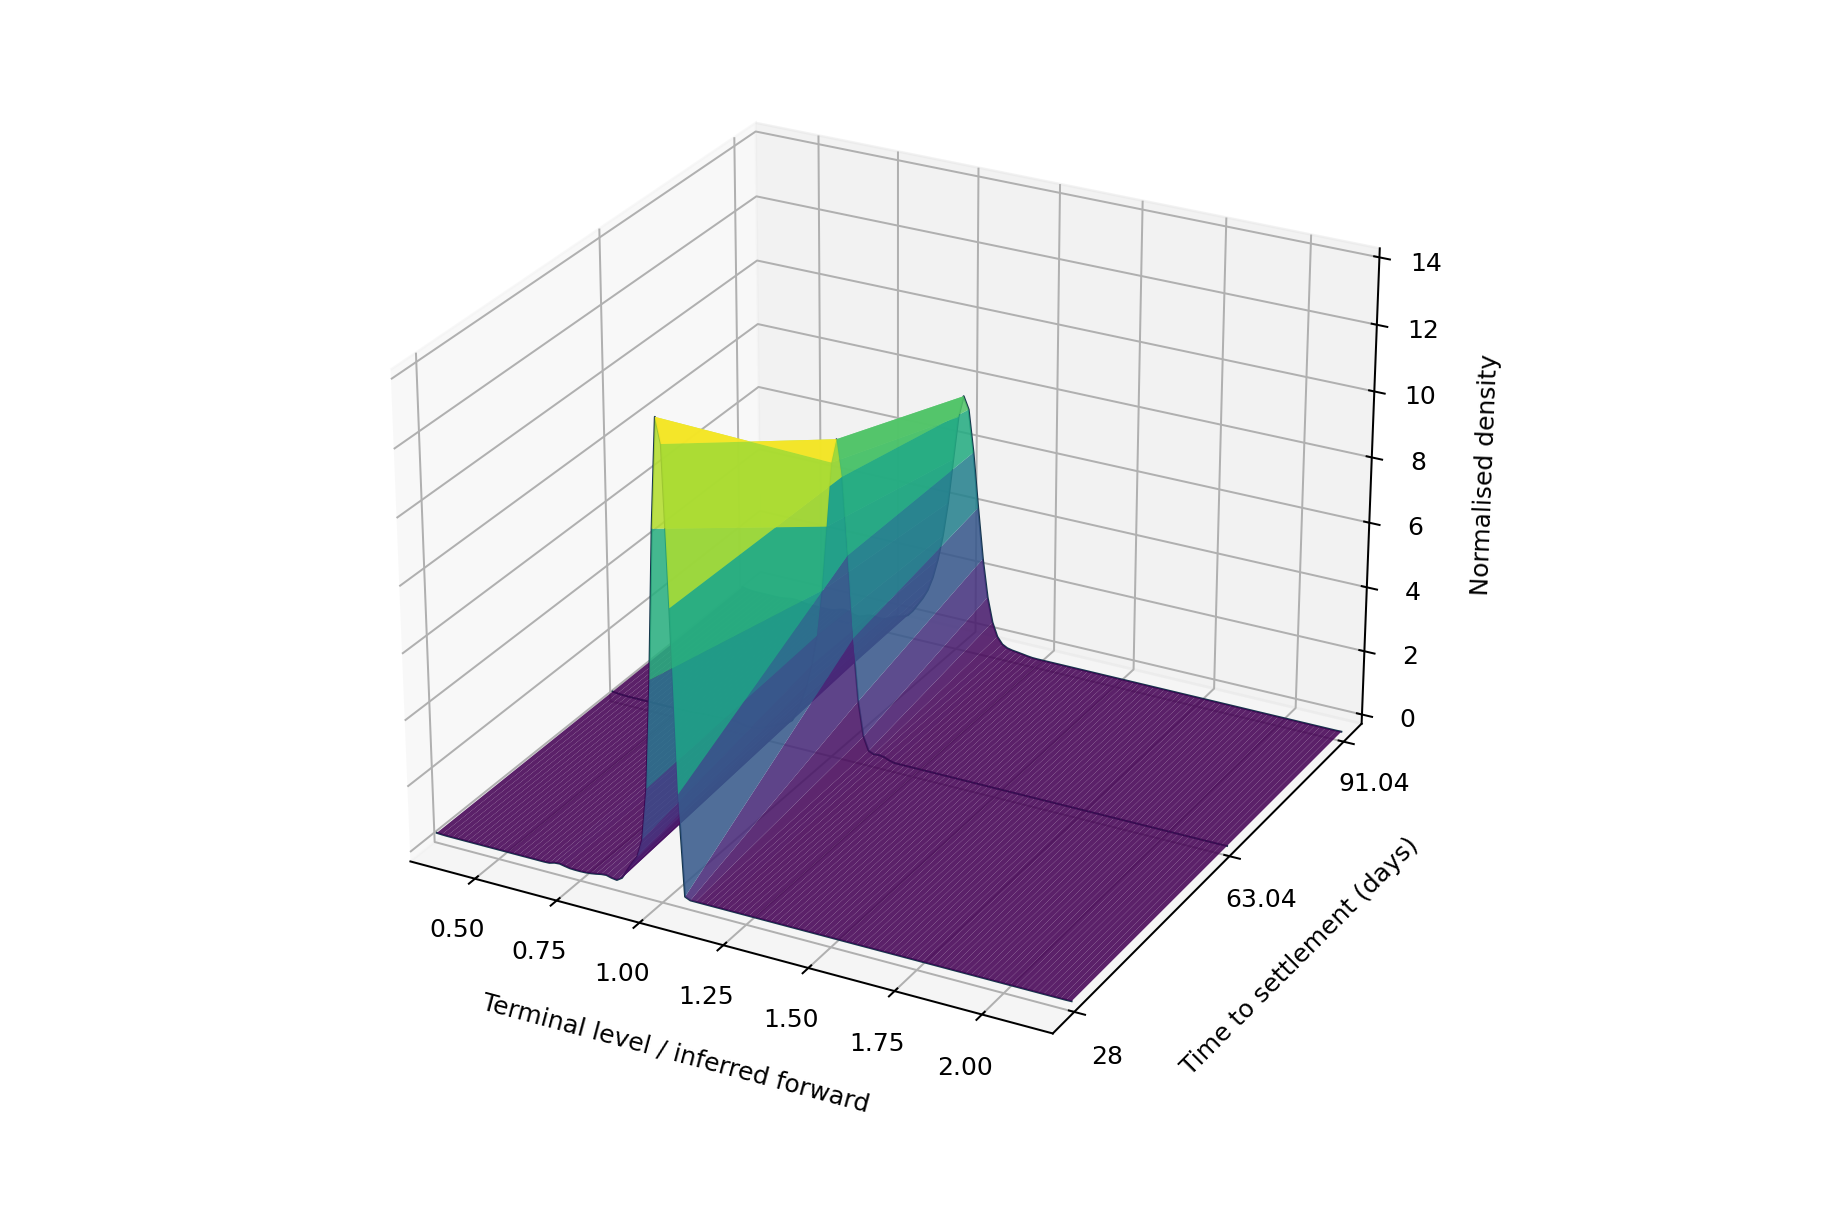




**Figure 28. The primary selected empirical density across three settlement horizons.** The surface connects bin centres and the three fitted maturity curves for visual guidance. It is not a fitted continuum of maturities. The horizontal terminal-level coordinate is normalised by each expiry's inferred forward; the vertical coordinate is its corresponding density. Exact steps and alternative smoothing choices are available in the [offline empirical explorer](interactive/empirical_density_surface.html).

The explorer supports rotation, zoom, hover, coefficient selection, full-support/central views, a linked exact histogram and maturity play/pause. It carries the post-hoc labels and spread-miss counts with each choice. This is a maturity animation at one observation date, not the historical-date animation planned for Notebook 10. Both earlier synthetic explorers and all eight earlier notebooks remain unchanged, including the Figure 4 explanation below its figure and caption.

## 14. What is complete and what follows

Notebook 9 now contains its synthetic preparation and the first traceable empirical calibration. The dataset question is resolved for this scope: the supplied files support market-price estimation with inferred carry and explicit depth limitations. They also supply a reserved second date and a later same-day snapshot. They do not supply a long historical sample, independently observed discount inputs, a known terminal density or statistical uncertainty bands.

Notebook 10 is the remaining planned analytical notebook. It will examine empirical fit limitations and compare the reserved observations with consistent contract and horizon treatment, then provide date-aware interaction. The cross-date exercise must distinguish time passing towards a fixed expiry from a change in the same-horizon distribution. The combined paper follows, with the title page, abstract, contents, numbered lists, abbreviations and mathematical symbols already specified in the [paper registers](research/paper_registers.md).

The [development reflection](research/development_reflection.md) records the source-field distinction, missing curve workaround, training-only carry inference, smoothing-boundary finding, remaining put residuals and extrapolation sensitivity. Run `python build_milestone9_notebook.py` to recompute both parts, figures, tables and the offline companion entirely from archived inputs. `run_marking_calibration.py` and `run_marking_diagnostic.py` separately reproduce the empirical calculations. Theory references remain scholarly [1, 10–12, 14–15, 17]; Cboe [5, 21–22] supports provider and contract facts. Full bibliographic records are in [references.md](research/references.md).
